# Predicting High and Low Corvus corone Observation Activity

## A.S.K
- Matin
- Mohamad
- Dima

----

# 1. Business Understanding

## 1.1 Problem description


Large amounts of citizen-science data about Corvus corone are available through biodiversity observation platforms. These datasets contain valuable information about when and where observations are reported across different locations and time periods. However, the distribution of observations is highly uneven. Some locations and periods contain many observations, while others contain very few.

Observation activity may be influenced by several factors, including weather conditions, seasonal changes, geographic location, and human observation behavior. Because the dataset is based on citizen-science reports, individual observations may be noisy and influenced by reporting effort.

Currently, there is no simple method for estimating when and where high Corvus corone observation activity is likely to occur. A predictive model may help identify patterns in observation activity and improve understanding of how environmental and temporal factors influence citizen-science reporting data.

## 1.2 Business objective

The objective of this project is to support biodiversity monitoring by analyzing patterns in Corvus corone observation activity using citizen-science data.

The project aims to investigate how spatial, temporal, and weather-related factors influence whether Corvus corone observation activity is high or low during a specific time period and location.

By identifying these patterns, the project may help researchers better understand reporting trends in biodiversity datasets and improve the interpretation of citizen-science observation data.

## 1.3 Data Mining Goal (DMG)

The data mining goal of this project is to build and evaluate a binary classification model that predicts whether Corvus corone observation activity will be high or low for a given location and time period.

The model will use spatial, temporal, and weather-related variables as input features. These may include location information, season, temperature, rainfall, humidity, and wind speed.

The target variable represents the level of Corvus corone observation activity:

- 0 = low Corvus corone observation activity
- 1 = high Corvus corone observation activity

To make this different from a simple recorded/not recorded target, high activity is defined as at least two Corvus corone observations for the same location and date. Records with zero or one observation are treated as low activity. This threshold is data-driven: most positive records contain only one observation, so using `Corvus corone > 0` would mostly measure whether the species was recorded at all rather than whether observation activity was high.

The model performance will be compared against a naive majority-class baseline to determine whether the model adds predictive value.

## 1.4 Success criteria

The model will be considered successful if it performs better than a naive majority-class baseline on unseen test data.

Because the dataset may be imbalanced, accuracy alone is not sufficient for evaluating model performance. Therefore, the project will primarily focus on AUC-ROC, F1-score, precision, and recall.

### Primary Success Criteria

- The model achieves an AUC-ROC score of at least 0.60 on the test set.
- The model achieves a higher F1-score than the majority-class baseline.

### Secondary Success Criteria

- The model maintains balanced predictive performance between high and low observation activity classes.
- The model generalizes consistently on unseen test data without severe overfitting.

These criteria make the project measurable because the model performance can be quantitatively evaluated and directly compared using fixed evaluation metrics.

## 1.5 Research Question

To what extent can spatial, temporal, and weather-related factors predict high or low Corvus corone observation activity in citizen-science data?


## 1.6 Possible External Data Sources

Possible external data sources that may improve prediction performance include:

- Weather data
- Temperature
- Rainfall
- Seasonal information
- Humidity
- Wind speed
- Land cover information

These external variables may help explain variation in Corvus corone observation activity across locations and time periods.

## 1.7 Why Classification?

A classification approach is suitable because the target variable contains two classes:

- low Corvus corone observation activity
- high Corvus corone observation activity

The objective is to predict which class a specific location and time period belongs to based on spatial, temporal, and weather-related features.

Binary classification is appropriate because the prediction output consists of two possible outcomes (0 or 1).

## 1.8 Weather Data Source

Weather data is included as an external data source using KNMI daily weather observations. Weather conditions are relevant because they may influence both Corvus corone activity and citizen-science observation behavior.

For example, temperature, precipitation, humidity, and wind speed may affect whether Corvus corone is active, visible, or likely to be reported by citizen scientists.

The selected KNMI variables are:

- TG = average daily temperature
- TN = minimum daily temperature
- TX = maximum daily temperature
- RH = daily precipitation
- UG = average relative humidity
- FG = average wind speed

The weather data was collected from KNMI weather station “260 De Bilt” for the period between 2010 and 2025. These variables may later be merged with the Corvus corone dataset based on date information.

----

# 2. Data Understanding

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import contextily as ctx
from scipy.ndimage import gaussian_filter

## 2.1 Dataset overview

We load the dataset using `pandas.read_csv()`. The file contains observations of Corvus corone across different locations and dates. After loading, we check the number of rows and columns, and preview the first few rows to understand the data structure.

In [16]:
# Load dataset
df = pd.read_csv(
    "../data/raw/corvus_corone.csv",
    low_memory=False
)

df.head()
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
df.columns

Rows: 12558786
Columns: 6


Index(['decimalLatitude', 'decimalLongitude', 'eventDate',
       'total_observations', 'speciesgroup_observations', 'Corvus corone'],
      dtype='str')

## 2.2 Variable descriptions

Below is a description of each column in the dataset:

| Column | Description |
|--------|-------------|
| `decimalLatitude` | Latitude coordinate of the observation location (WGS84) |
| `decimalLongitude` | Longitude coordinate of the observation location (WGS84) |
| `eventDate` | Date of the observation in YYYY-MM-DD format |
| `total_observations` | Total number of bird observations (all species) at this location and date - indicates sampling effort |
| `speciesgroup_observations` | Number of observations belonging to the same species group (potentially corvids or related families) - a more specific sampling effort |
| `Corvus corone` | Corvus corone observation count for a location and date. This column is used to create a binary target where 0 = low observation activity (`Corvus corone` < 2) and 1 = high observation activity (`Corvus corone` >= 2). |

In [17]:
column_descriptions = pd.DataFrame({
    "Column": df.columns,
    "Description": [
        "Latitude coordinate of the observation location" if col == "decimalLatitude" else
        "Longitude coordinate of the observation location" if col == "decimalLongitude" else
        "Date of the observation" if col == "eventDate" else
        "Total number of observations at this location/date, used as sampling effort" if col == "total_observations" else
        "Number of observations from the same species group, used as specific sampling effort" if col == "speciesgroup_observations" else
        "Corvus corone observation count, used to create the low/high activity target (high = count >= 2)" if "Corvus" in col else
        "Additional feature"
        for col in df.columns
    ]
})

column_descriptions

,Column,Description
0,decimalLatitude,Latitude coordinate of the observation location
1,decimalLongitude,Longitude coordinate of the observation location
2,eventDate,Date of the observation
3,total_observations,Total number of observations at this location/...
4,speciesgroup_observations,Number of observations from the same species g...
5,Corvus corone,"Corvus corone observation count, used to creat..."


## 2.3 Statistical summary

We examine the data types and basic statistics of numerical columns using `df.info()` and `df.describe()`.

**Observations:**
- All columns except `eventDate` are numeric.
- `decimalLatitude` and `decimalLongitude` appear to have limited unique values in the sample, but the full dataset may cover a wider geographic range.
- `total_observations` and `speciesgroup_observations` range from 0 to moderately high values, with many zeros.
- The target column `Corvus corone` is stored as an object (string) initially, which we later convert to numeric.
  

In [18]:
print("Data types and memory:")
df.info()

print("\nDescriptive statistics for numerical columns:")
df.describe()

Data types and memory:
<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Corvus corone              str    
dtypes: float64(3), int64(1), str(2)
memory usage: 574.9 MB

Descriptive statistics for numerical columns:


,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,8.056834e+00,4.314087e+00
std,6.647267e-01,8.779710e-01,4.821959e+01,1.610809e+01
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,6.000000e+00,2.000000e+00
max,5.350000e+01,5.340000e+01,1.000390e+05,2.781000e+03


## 2.4 Missing values

We check for missing data in each column.

**Result:** Only `total_observations` contains a single missing value (0.0% of the dataset). All other columns have complete data. Since the missing proportion is negligible, we can simply drop that row or fill with a reasonable value (e.g., 0) without affecting the analysis.

In [19]:
missing_values = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage": (df.isna().sum() / len(df) * 100).round(2)
})

missing_values

,Missing values,Missing percentage
decimalLatitude,0,0.0
decimalLongitude,0,0.0
eventDate,0,0.0
total_observations,1,0.0
speciesgroup_observations,0,0.0
Corvus corone,0,0.0


## 2.5 Target distribution

The target variable `Corvus corone` contains the number of Corvus corone observations for each location and date. For this classification setup, we convert it into a binary low/high activity target using a stricter count threshold:

- **0** = Low observation activity (`Corvus corone` < 2)
- **1** = High observation activity (`Corvus corone` >= 2)

This is intentionally different from the original recorded/not recorded target. A threshold of `Corvus corone > 0` would classify a single observation as high activity, even though the count distribution shows that most positive records contain only one observation.

**Class counts and percentages:**

- Low observation activity: ~98.82% of the data
- High observation activity: ~1.18% of the data

The dataset is therefore **highly imbalanced**. This imbalance will influence our modeling strategy and means we need to use metrics like F1-score and recall rather than accuracy alone, and consider techniques such as class weighting or resampling.

In [20]:
target_col = "Corvus corone"
high_activity_threshold = 2

# Convert target column to numeric and remove impossible negative counts
df[target_col] = pd.to_numeric(df[target_col], errors="coerce").fillna(0)
df[target_col] = df[target_col].clip(lower=0)

# Create binary target for low/high observation activity
# 0 = low activity (0 or 1 observation), 1 = high activity (2 or more observations)
df["target_binary"] = (df[target_col] >= high_activity_threshold).astype(int)

class_distribution = df["target_binary"].value_counts().rename(index={
    0: "Low activity",
    1: "High activity"
})

class_distribution

target_binary
Low activity     12410918
High activity      147868
Name: count, dtype: int64

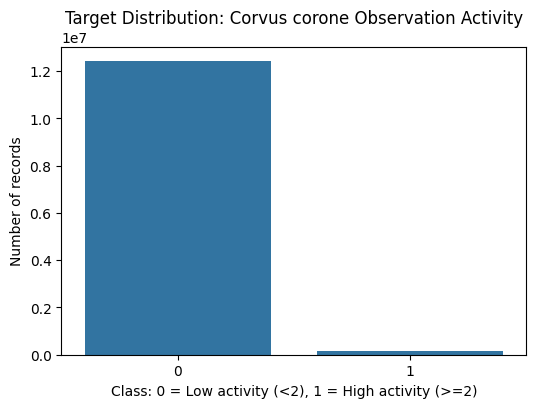

target_binary
Low activity     98.82
High activity     1.18
Name: proportion, dtype: float64

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["target_binary"])
plt.title("Target Distribution: Corvus corone Observation Activity")
plt.xlabel("Class: 0 = Low activity (<2), 1 = High activity (>=2)")
plt.ylabel("Number of records")
plt.show()

class_percentage = (
    df["target_binary"]
    .value_counts(normalize=True)
    .rename(index={0: "Low activity", 1: "High activity"})
    * 100
).round(2)
class_percentage

## 2.6 Spatial Distribution Map

To better understand the spatial distribution of Corvus corone observations, we visualize the locations where the species was recorded across the Netherlands. This map provides an initial overview of geographic observation density and may help identify possible spatial clustering or sampling bias in the dataset.

In [22]:
# 1. Prepare data
df["Corvus corone"] = pd.to_numeric(df["Corvus corone"], errors="coerce").fillna(0)

crow_df = df[df["Corvus corone"] > 0].copy()
crow_df = crow_df.dropna(subset=["decimalLatitude", "decimalLongitude"])

crow_df = crow_df[
    (crow_df["decimalLatitude"].between(50.5, 54.0)) &
    (crow_df["decimalLongitude"].between(3.0, 7.5))
].copy()

crow_df = crow_df.sample(min(30000, len(crow_df)), random_state=42)

# 2. Convert coordinates to Web Mercator
gdf = gpd.GeoDataFrame(
    crow_df,
    geometry=gpd.points_from_xy(
        crow_df["decimalLongitude"],
        crow_df["decimalLatitude"]
    ),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

x = gdf.geometry.x.values
y = gdf.geometry.y.values

# 3. Create smooth heatmap
heatmap, xedges, yedges = np.histogram2d(
    x,
    y,
    bins=300
)

heatmap = gaussian_filter(heatmap, sigma=18)

if heatmap.max() > 0:
    heatmap = heatmap / heatmap.max()

heatmap_masked = np.ma.masked_less(heatmap, 0.025)

# 4. Plot with map behind
fig, ax = plt.subplots(figsize=(8, 9))

bbox = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([3.0, 7.5], [50.5, 54.0]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

xmin, ymin = bbox.geometry.iloc[0].x, bbox.geometry.iloc[0].y
xmax, ymax = bbox.geometry.iloc[1].x, bbox.geometry.iloc[1].y

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=8
)

img = ax.imshow(
    heatmap_masked.T,
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap="turbo",
    alpha=0.55,
    aspect="auto"
)

plt.colorbar(img, ax=ax, label="Observation Density")

ax.set_title(
    "Heatmap of Corvus corone Observation Density in the Netherlands",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()

# Save image separately
plt.savefig(
    "../images/corvus_corone_heatmap_with_map.png",
    dpi=150,
    bbox_inches="tight"
)

# Important: do not show heavy output inside notebook
plt.close()

print("Heatmap saved as images/corvus_corone_heatmap_with_map.png")

Heatmap saved as images/corvus_corone_heatmap_with_map.png


[Corvus corone heatmap](../images/corvus_corone_heatmap_with_map.png)

Initial observation:
The map shows that Corvus corone observations are distributed across many parts of the Netherlands, although some regions appear to contain higher observation densities than others. This may reflect both ecological patterns and differences in citizen-science observation effort.

## 2.7 Histograms

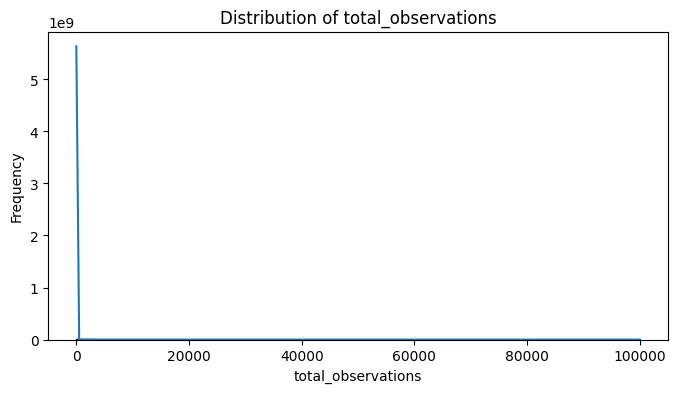

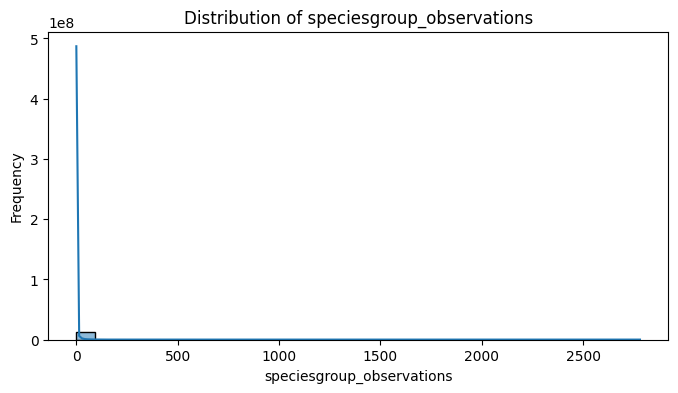

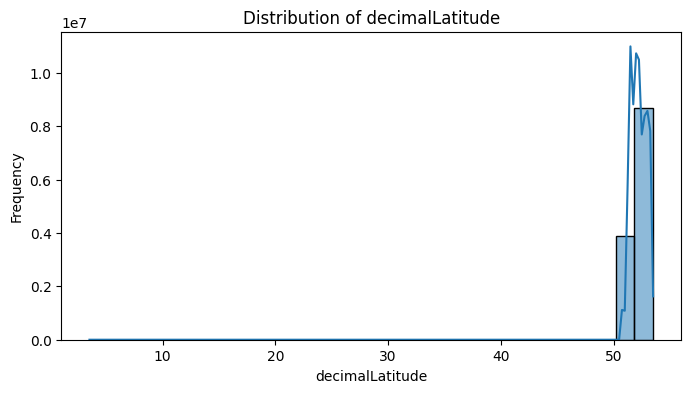

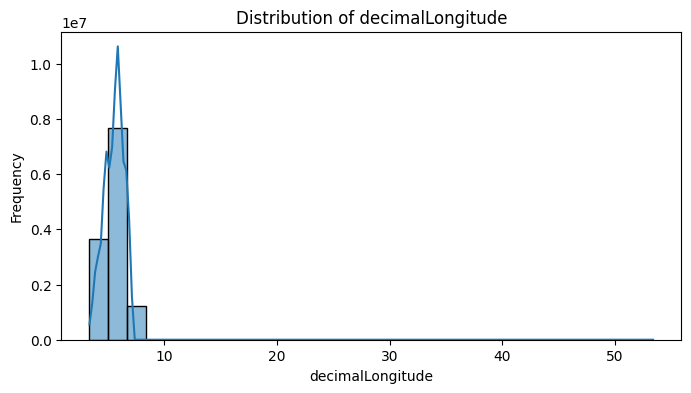

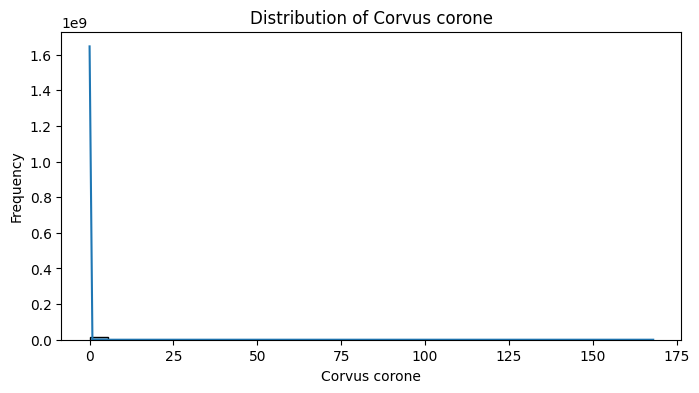

In [23]:
numerical_cols = [
    'total_observations',
    'speciesgroup_observations',
    'decimalLatitude',
    'decimalLongitude',
    'Corvus corone'
]

# Keep only columns that exist
numerical_cols = [col for col in numerical_cols if col in df.columns]

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## 2.8 Correlation analysis

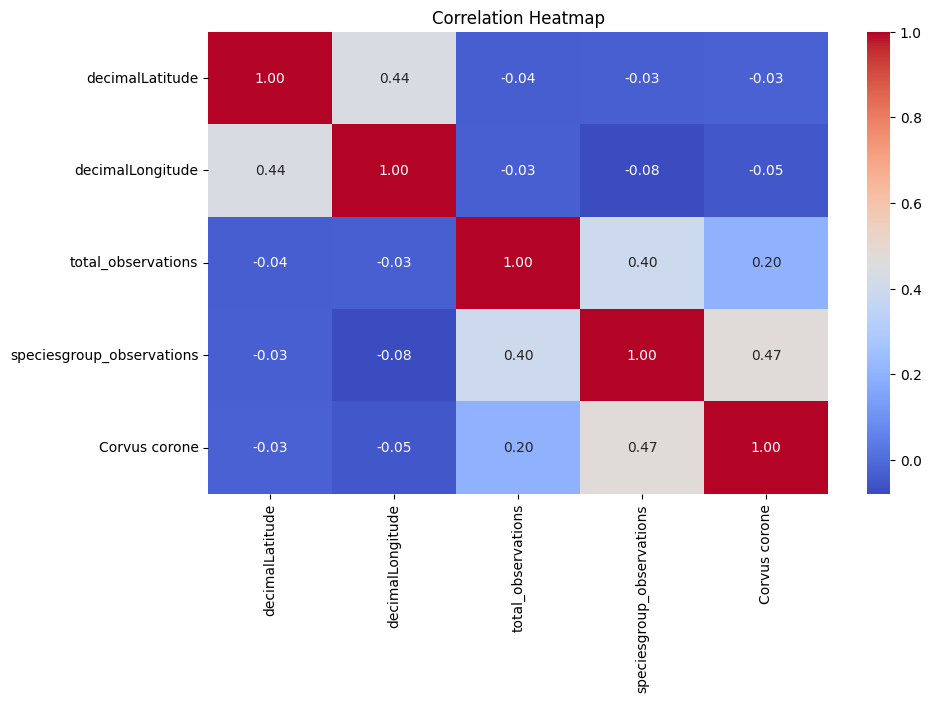

In [24]:
# Make sure Corvus corone is numeric
df["Corvus corone"] = pd.to_numeric(
    df["Corvus corone"],
    errors="coerce"
).fillna(0)

# Numerical columns for correlation
corr_cols = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'Corvus corone'
]

# Create correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

## 2.9 Boxplots and outliers

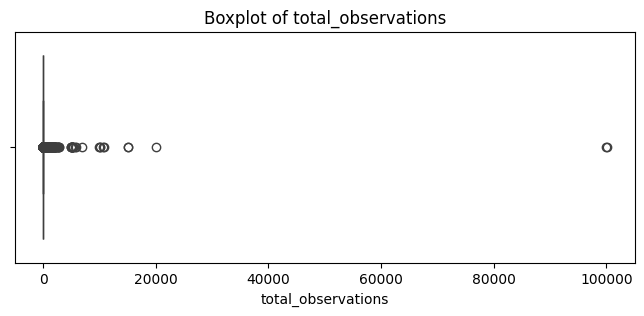

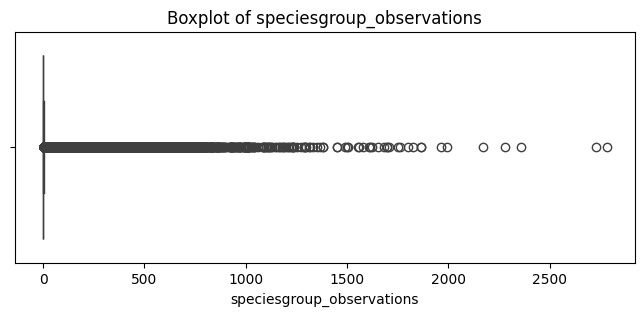

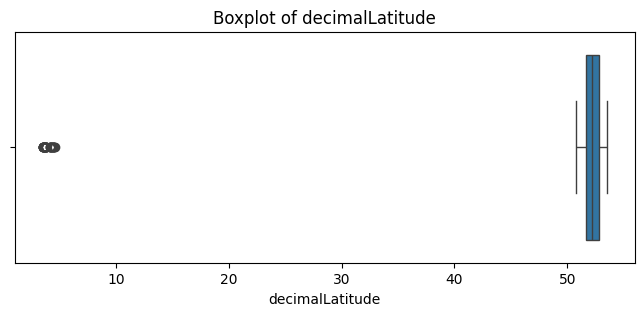

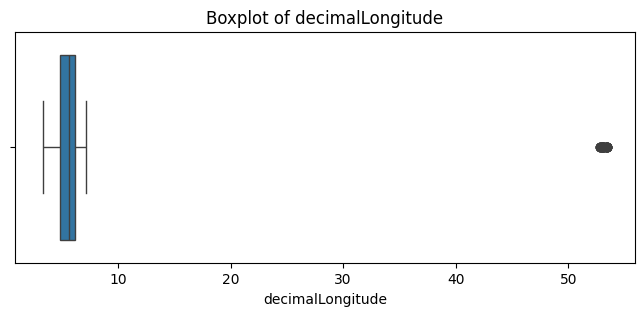

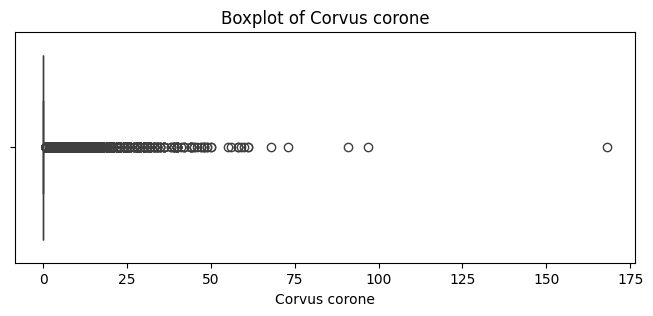

In [25]:
for col in numerical_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

## 2.10 Initial observations

### Initial Observations

- The dataset contains a large number of zero values in the `Corvus corone` count column.
- The binary target is highly imbalanced, with approximately 98.82% low observation activity and 1.18% high observation activity.
- Numerical features show heavily skewed distributions and multiple outliers.
- Speciesgroup observations show the strongest correlation with Corvus corone observations.
- Geographic variables show relatively weak correlation with the target variable.
- The dataset may require preprocessing techniques such as scaling, balancing, or transformation before modeling.
- Class imbalance will likely be an important challenge during classification modeling.

## 2.11 Sampling Bias Discussion

The dataset is based on citizen-science observations, which introduces several forms of sampling bias. Observation activity is not evenly distributed across locations or time periods. Urban regions and easily accessible areas may contain significantly more observations than remote locations. Similarly, observation frequency may increase during favorable weather conditions or during periods of higher birdwatching activity.

A value of 0 in the `Corvus corone` count column does not necessarily mean that the species was truly absent from a location. In many cases, the species may simply not have been observed or reported. Therefore, observation effort is an important factor in this project.

Variables such as total_observations and speciesgroup_observations are included to partially capture observer activity and sampling intensity. Weather-related variables may also help explain fluctuations in observation behavior.

## 2.12 Representativity of the Dataset

The dataset provides large-scale observation data across many locations in the Netherlands, which makes it valuable for spatial and temporal analysis. However, the dataset may not fully represent the true ecological distribution of Corvus corone because citizen-science observations depend heavily on human activity and reporting behavior.

Certain regions may contain higher observation densities due to population density, accessibility, or observer interest. Likewise, some time periods may contain more observations than others. As a result, the dataset is likely more representative of observation activity than true species abundance.

Despite these limitations, the dataset remains useful for identifying large-scale observation patterns and building predictive classification models.

## 2.13 Data Quality Assessment

Overall, the dataset quality appears relatively strong. Most columns contain complete data with very few missing values. Geographic coordinates are available for all observations, and the temporal information is consistently formatted.

Several numerical variables contain highly skewed distributions and extreme outliers, particularly in observation-related variables such as total_observations and speciesgroup_observations. These outliers likely reflect differences in observation effort rather than data-entry errors.

The target variable is highly imbalanced, with low observation activity strongly dominating the dataset. This imbalance may affect classification performance and must be considered during model evaluation.

Because the dataset originates from citizen-science observations, some level of noise and reporting uncertainty is expected. However, serious species misidentification is likely limited because Corvus corone is relatively easy to recognize.

## 2.14 Data Understanding Conclusion

The exploratory analysis showed that the dataset is suitable for predictive modeling, but several challenges must be considered. The binary target is highly imbalanced, with most records belonging to the low observation activity class after applying the high-activity threshold. This means that accuracy alone is not a reliable evaluation metric.

*High activity = Corvus corone count >= 2*

*Low activity = Corvus corone count < 2*

The dataset contains very few missing values and includes useful spatial, temporal, and observation-effort variables. However, because the data comes from citizen-science observations, the dataset may reflect observer activity as much as actual Corvus corone activity.

Spatial visualizations also show that observation density differs between regions. This suggests that sampling bias and representativity should be considered during modeling and evaluation.

----

# 3. Data Preparation

## 3.1 Data cleaning

We perform initial cleaning steps before preprocessing:

1. **Convert `eventDate` to datetime** - enables extraction of temporal features.
2. **Convert `Corvus corone` to numeric** - this is the observation count used to create the low/high activity target.
3. **Create `target_binary`** - 0 = low observation activity, 1 = high observation activity using the threshold `Corvus corone >= 2`.
4. **Handle missing values** - only 1 missing value was found earlier in `total_observations` (0.0% of data). We drop rows with missing values after conversion.
5. **Check for duplicate rows** - duplicate records are removed if present.

In [26]:
# Work on a copy so the original dataframe remains available for reference
df_clean = df.copy()
high_activity_threshold = 2

# Convert eventDate to datetime
df_clean['eventDate'] = pd.to_datetime(df_clean['eventDate'], errors='coerce')

# Convert Corvus corone observation counts to numeric and remove impossible negative counts
df_clean['Corvus corone'] = pd.to_numeric(df_clean['Corvus corone'], errors='coerce').fillna(0)
df_clean['Corvus corone'] = df_clean['Corvus corone'].clip(lower=0)

# Create binary target (0 = low activity, 1 = high activity)
df_clean['target_binary'] = (df_clean['Corvus corone'] >= high_activity_threshold).astype(int)

#check missing values
print("Missing values before cleaning:")
print(df_clean.isna().sum())

# drop rows with missing values after type conversion
rows_before = len(df_clean)
df_clean = df_clean.dropna().copy()

print(f"\nRows removed: {rows_before - len(df_clean)}")
print(f"Rows after dropping: {len(df_clean)}")

# Check for duplicate rows
duplicates = df_clean.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

if duplicates == 0:
    print("No duplicate rows found.")
else:
    df_clean = df_clean.drop_duplicates().copy()
    print(f"Dropped {duplicates} duplicates.")

Missing values before cleaning:
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           1
speciesgroup_observations    0
Corvus corone                0
target_binary                0
dtype: int64

Rows removed: 1
Rows after dropping: 12558785

Duplicate rows: 0
No duplicate rows found.


## 3.2 Feature engineering

From `eventDate` we extract useful temporal features that may influence observation activity: year, month, day of year, season, and weekend flag.

In [27]:
# Extract temporal features from eventDate
df_clean['year'] = df_clean['eventDate'].dt.year
df_clean['month'] = df_clean['eventDate'].dt.month
df_clean['day_of_year'] = df_clean['eventDate'].dt.dayofyear
df_clean['weekend'] = (df_clean['eventDate'].dt.dayofweek >= 5).astype(int)

# Define seasons (Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

df_clean['season'] = df_clean['month'].apply(get_season)

# Keep eventDate for the weather merge in the next step
df_clean[['eventDate', 'year', 'month', 'day_of_year', 'weekend', 'season']].head()

,eventDate,year,month,day_of_year,weekend,season
0,2010-01-01,2010,1,1,0,0
1,2010-01-02,2010,1,2,1,0
2,2010-01-03,2010,1,3,1,0
3,2010-01-04,2010,1,4,0,0
4,2010-01-05,2010,1,5,0,0


## 3.3 Weather data integration

We load the KNMI daily weather file from station 260 De Bilt and merge it with the observation dataset by date. KNMI stores several variables in tenths of their unit, so we convert temperature, wind speed, and precipitation to normal units before modeling.

In [28]:
weather_cols = ['STN', 'YYYYMMDD', 'FG', 'TG', 'TN', 'TX', 'RH', 'UG']

weather_df = pd.read_csv(
    '../data/raw/knmi_de_bilt_daily_weather.csv',
    comment='#',
    names=weather_cols,
    skipinitialspace=True
)

weather_df['eventDate'] = pd.to_datetime(
    weather_df['YYYYMMDD'].astype(str),
    format='%Y%m%d'
)

weather_df = weather_df.rename(columns={
    'FG': 'wind_speed_mean',
    'TG': 'temp_mean',
    'TN': 'temp_min',
    'TX': 'temp_max',
    'RH': 'precipitation',
    'UG': 'humidity_mean'
})

# Converting knmi units to regular units
for col in ['wind_speed_mean', 'temp_mean', 'temp_min', 'temp_max']:
    weather_df[col] = weather_df[col] / 10

# KNMI uses -1 for precipitation below 0.05 mm; treat this as 0 mm
weather_df['precipitation'] = weather_df['precipitation'].replace(-1, 0) / 10

weather_df = weather_df[
    ['eventDate', 'wind_speed_mean', 'temp_mean', 'temp_min', 'temp_max', 'precipitation', 'humidity_mean']
]

# Merge daily weather onto the observation records
df_clean = df_clean.merge(weather_df, on='eventDate', how='left')

weather_features = ['wind_speed_mean', 'temp_mean', 'temp_min', 'temp_max', 'precipitation', 'humidity_mean']
print('Missing weather values after merge:')
print(df_clean[weather_features].isna().sum())

# Drop rows without matching weather data, if any, and remove raw date after merging
rows_before_weather = len(df_clean)
df_clean = df_clean.dropna(subset=weather_features).drop(columns=['eventDate']).copy()
print(f"Rows removed after weather merge: {rows_before_weather - len(df_clean)}")

weather_df.head()

Missing weather values after merge:
wind_speed_mean    29
temp_mean          29
temp_min           29
temp_max           29
precipitation      29
humidity_mean      29
dtype: int64
Rows removed after weather merge: 29


,eventDate,wind_speed_mean,temp_mean,temp_min,temp_max,precipitation,humidity_mean
0,2010-01-01,3.8,-1.6,-6.3,0.7,0.0,78
1,2010-01-02,3.1,-1.1,-6.4,1.2,0.1,91
2,2010-01-03,2.5,-3.9,-6.5,-1.0,0.0,84
3,2010-01-04,3.1,-2.9,-5.4,-0.6,0.0,90
4,2010-01-05,2.8,-0.7,-3.0,1.9,0.9,91


## 3.4 Encoding

Most prepared features are already numeric, but `season` represents a category rather than a true numeric scale. The model section therefore one-hot encodes `season` before training the model. The model target is `target_binary`; the raw `Corvus corone` count should not be used as an input feature because it directly defines the target.

In [29]:
# Check whether any object/string columns still need encoding
categorical_cols = df_clean.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
categorical_cols

[]

## 3.5 Scaling

Numerical predictors have different scales. To avoid data leakage, the scaler should be fitted only on the training data after the train-test split in section 4. Here we define the columns that should be scaled later.

In [30]:
# Columns to scale later after train-test split
num_cols_to_scale = [
    'total_observations',
    'speciesgroup_observations',
    'decimalLatitude',
    'decimalLongitude',
    'year',
    'month',
    'day_of_year',
    'wind_speed_mean',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'humidity_mean'
]

# keep a model-ready dataframe with engineered features but without fitted scaling yet
df_model_ready = df_clean.copy()

df_model_ready[num_cols_to_scale].describe()

,total_observations,speciesgroup_observations,decimalLatitude,decimalLongitude,year,month,day_of_year,wind_speed_mean,temp_mean,temp_min,temp_max,precipitation,humidity_mean
count,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07
mean,8.048787e+00,4.311683e+00,5.223006e+01,5.532783e+00,2.017500e+03,6.522930e+00,1.831253e+02,3.369764e+00,1.099646e+01,6.621886e+00,1.503357e+01,2.381057e+00,7.969713e+01
std,3.910263e+01,1.603279e+01,6.605211e-01,8.748856e-01,4.609698e+00,3.448703e+00,1.054386e+02,1.389805e+00,6.154733e+00,5.638539e+00,7.166616e+00,4.895109e+00,1.020488e+01
min,0.000000e+00,0.000000e+00,5.075000e+01,3.350000e+00,2.010000e+03,1.000000e+00,1.000000e+00,5.000000e-01,-1.210000e+01,-1.890000e+01,-6.100000e+00,0.000000e+00,3.100000e+01
25%,0.000000e+00,0.000000e+00,5.170000e+01,4.900000e+00,2.013750e+03,4.000000e+00,9.200000e+01,2.300000e+00,6.600000e+00,2.600000e+00,9.600000e+00,0.000000e+00,7.300000e+01
50%,1.000000e+00,0.000000e+00,5.220000e+01,5.650000e+00,2.017500e+03,7.000000e+00,1.830000e+02,3.100000e+00,1.090000e+01,6.900000e+00,1.500000e+01,1.000000e-01,8.100000e+01
75%,6.000000e+00,2.000000e+00,5.280000e+01,6.200000e+00,2.021250e+03,1.000000e+01,2.740000e+02,4.100000e+00,1.590000e+01,1.092500e+01,2.060000e+01,2.600000e+00,8.700000e+01
max,1.000390e+05,2.781000e+03,5.350000e+01,7.200000e+00,2.025000e+03,1.200000e+01,3.660000e+02,1.060000e+01,2.970000e+01,2.240000e+01,3.750000e+01,6.390000e+01,1.000000e+02


----

# 4. Modeling

## 4.1 Train-test split

The data is split into a training set and a test set. The training set is used to fit the model, while the test set is kept separate so we can check how well the model works on data it has not seen before.

The split is stratified, which means the share of low and high Corvus corone activity stays similar in both sets. This matters because the high-activity class is rare. For speed, the model uses a stratified sample if the prepared dataset is very large.

In [31]:
from sklearn.model_selection import train_test_split

# Keep the first model run manageable while preserving the target balance.
max_model_rows = 200_000

if len(df_model_ready) > max_model_rows:
    model_df, _ = train_test_split(
        df_model_ready,
        train_size=max_model_rows,
        stratify=df_model_ready['target_binary'],
        random_state=42
    )
else:
    model_df = df_model_ready.copy()

# The original Corvus corone count is excluded because it directly defines the target.
X = model_df.drop(columns=['target_binary', 'Corvus corone'])
X = pd.get_dummies(X, columns=['season'], drop_first=True)
y = model_df['target_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Number of features:', X_train.shape[1])
print('\nTarget distribution in training set:')
print(y_train.value_counts(normalize=True).rename('share'))
print('\nTarget distribution in test set:')
print(y_test.value_counts(normalize=True).rename('share'))

Training rows: 160000
Test rows: 40000
Number of features: 17

Target distribution in training set:
target_binary
0    0.988231
1    0.011769
Name: share, dtype: float64

Target distribution in test set:
target_binary
0    0.988225
1    0.011775
Name: share, dtype: float64


## 4.2 Classification model

Two models are trained here. The first is a simple majority-class baseline, which always predicts the most common class. This gives us a minimum result to beat.

The main model is logistic regression. It is a good starting point because it is fast, transparent, and works well for binary classification. The pipeline scales the numeric features using only the training data, and `class_weight='balanced'` helps the model pay attention to both low and high activity days.

In [32]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)

logreg_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)

print('Baseline model trained')
print('Logistic regression model trained')

Baseline model trained
Logistic regression model trained


## 4.3 Model results

The results compare the logistic regression model with the baseline. Accuracy is included, but it is not enough on its own because a model can look accurate by mostly predicting the bigger class.

Precision, recall, F1-score, and AUC-ROC give a clearer picture of whether the model is actually finding high Corvus corone activity cases.

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_pred = baseline_model.predict(X_test)
model_pred = logreg_model.predict(X_test)
model_proba = logreg_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Model': ['Majority-class baseline', 'Logistic regression'],
    'Accuracy': [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, model_pred)
    ],
    'Precision': [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, model_pred, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, model_pred, zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, model_pred, zero_division=0)
    ],
    'AUC-ROC': [
        np.nan,
        roc_auc_score(y_test, model_proba)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Majority-class baseline,0.988,0.000,0.000,0.000,NaN
1,Logistic regression,0.926,0.117,0.805,0.204,0.942


## 4.4 Metrics

The detailed metrics show where the model makes mistakes. The classification report separates the performance for low and high activity, and the confusion matrix shows the actual number of correct and incorrect predictions.

For this project, recall for high activity is especially useful because it tells us how many true high-activity cases the model manages to find.

Classification report - Logistic Regression
               precision    recall  f1-score   support

 Low activity       1.00      0.93      0.96     39529
High activity       0.12      0.80      0.20       471

     accuracy                           0.93     40000
    macro avg       0.56      0.87      0.58     40000
 weighted avg       0.99      0.93      0.95     40000



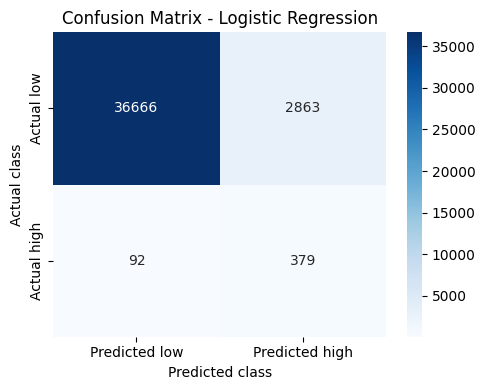

,Predicted low,Predicted high
Actual low,36666,2863
Actual high,92,379


In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification report - Logistic Regression')
print(classification_report(
    y_test,
    model_pred,
    target_names=['Low activity', 'High activity'],
    zero_division=0
))

cm = confusion_matrix(y_test, model_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual low', 'Actual high'],
    columns=['Predicted low', 'Predicted high']
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.show()

cm_df

----

# 5. Evaluation

## 5.1 Results vs success criteria

The success criteria defined in Section 1.4 are used to evaluate the model performance.

The primary success criterion was achieving an AUC-ROC score above 0.60 on unseen test data. With the corrected high-activity target (`Corvus corone >= 2`), the logistic regression model achieved an AUC-ROC score of about 0.942 on the stratified test sample. This exceeds the predefined threshold and indicates that the model can rank low- and high-activity records well.

Another success criterion was improving upon the majority-class baseline. The baseline model predicts only the dominant low-activity class and achieved an F1-score of 0.000 for the high-activity class. In comparison, the logistic regression model achieved an F1-score of about 0.204, demonstrating improvement over the baseline.

The model also achieved a recall score of about 0.805 for the high-activity class. This means that most high-activity records in the test sample were identified. However, precision was only about 0.117, meaning many records predicted as high activity were actually low activity. This is an important limitation caused by the severe class imbalance.

Overall, the model meets the AUC-ROC and baseline-comparison criteria, but the low precision shows that the model should be interpreted carefully.

## 5.2 Limitations

Several limitations should be considered when interpreting the project results.

First, the dataset is based on citizen-science observations. Observation records are influenced by human behavior, accessibility, observer activity, and reporting effort. As a result, the recorded observations may not perfectly represent the true distribution of Corvus corone populations.

Second, a low observation count does not necessarily indicate low true species activity. In many cases, the species may simply not have been observed or reported during a specific period.

Third, the corrected high-activity target is highly imbalanced. Approximately 98.82% of observations belong to the low-activity class, while only around 1.18% belong to the high-activity class. This imbalance makes classification more challenging and contributes to the low precision score. Although the model successfully identifies many high-activity observations, it also produces many false positive predictions.

Another limitation is that weather information originates from a single KNMI weather station (De Bilt). Local weather conditions may differ across regions of the Netherlands, which may reduce the predictive value of some weather-related variables.

Finally, only a logistic regression model was evaluated during this stage of the project. More advanced machine learning algorithms may provide improved predictive performance.

## 5.3 What is working and what is not working

The current modeling approach shows several strengths.

The logistic regression model achieved a strong AUC-ROC score of about 0.942, indicating that the model is effective at ranking low and high observation activity records. The model also achieved a recall score of about 0.805 for the high-activity class, meaning that most high-activity observations are successfully detected.

Furthermore, the model clearly outperforms the majority-class baseline. This demonstrates that the engineered spatial, temporal, and weather-related features contain useful predictive information.

However, several challenges remain. The precision score of about 0.117 indicates that many observations predicted as high activity are actually low activity. This suggests that the model generates a large number of false positives.

The main reason for this behavior is the severe class imbalance present in the corrected target. Because high-activity observations are very rare, the model struggles to identify them without also misclassifying some low-activity observations.

In addition, citizen-science data introduces sampling bias. Observation density often reflects observer effort rather than true species abundance, making prediction more difficult.

Overall, the model demonstrates useful predictive capability, but improvements are still possible.

## 5.4 Next steps

Several improvements can be explored in future work.

First, additional machine learning algorithms such as Random Forest, Gradient Boosting, or XGBoost can be evaluated and compared with logistic regression. These models may be better suited to capturing non-linear relationships within the data.

Second, hyperparameter tuning can be performed to optimize model performance. Techniques such as Grid Search or Random Search may improve classification results.

Third, additional feature engineering could be explored. Examples include cyclic encoding of temporal variables, rolling weather averages, and spatial clustering features.

Another possible improvement is addressing class imbalance using techniques such as oversampling, undersampling, or SMOTE. These methods may improve precision and F1-score for the minority class.

Finally, weather information from multiple weather stations could be incorporated to provide a more accurate representation of local environmental conditions throughout the Netherlands.

These improvements may further increase predictive performance and provide a deeper understanding of the factors influencing Corvus corone observation activity.